# Oráculo: estimación de KDP

Oráculo de `docs/algorithms/kdp-estimacion.md`, independiente de cualquier
crate Rust (todavía no existe implementación — primer paso del método de
`docs/algorithms/roadmap.md` §"Método de estudio"). La página lo llama "el
algoritmo más delicado de todo el conjunto polarimétrico" y pide construir
la verdad-terreno integrando un KDP prescrito para obtener el perfil de ΦDP,
con ruido de fase acorde al ρHV y al número de pulsos — no un ruido
gaussiano añadido a mano: el ruido de fase de este notebook sale de simular
de verdad la estimación de la covarianza cruzada H/V, reutilizando
`generate_dual_pol_cell` de `polarimetria-covarianzas.md`.

**Fuera de alcance, declarado de entrada.** La página pide contrastar contra
`pyart.retrieve.kdp_*` sobre los mismos perfiles — el "mejor oráculo
disponible" para esta página. Esta sesión no tiene Py-ART instalado ni
acceso de red para instalarlo; el contraste externo queda pendiente,
explícito, no simulado ni inventado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260914)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_dual_pol_cell(power_h, mean_v, sigma_v, wavelength_m, prt_s, m, zdr_db, rho_hv, phidp_deg,
                            noise_floor, rng, wrap=3):
    power_v = power_h / 10.0 ** (zdr_db / 10.0)
    spec_h = gaussian_doppler_spectrum(power_h, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    spec_v = gaussian_doppler_spectrum(power_v, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    rho = rho_hv * np.exp(1j * np.radians(phidp_deg))
    l21, l22 = np.conj(rho), np.sqrt(1.0 - rho_hv ** 2)
    w1 = complex_gaussian(rng, 1.0, size=m)
    w2 = complex_gaussian(rng, 1.0, size=m)
    wh, wv = w1, l21 * w1 + l22 * w2
    yh = np.fft.ifft(wh * np.sqrt(spec_h)) * m
    yv = np.fft.ifft(wv * np.sqrt(spec_v)) * m
    if noise_floor > 0.0:
        yh = yh + complex_gaussian(rng, noise_floor, size=m)
        yv = yv + complex_gaussian(rng, noise_floor, size=m)
    return yh, yv


def measure_phidp(power_h, mean_v, sigma_v, wavelength_m, prt_s, m, rho_hv, phidp_true_deg, noise_floor, rng):
    """Un valor de PhiDP medido en una celda, con el ruido de fase que sale de
    verdad de estimar R_hv sobre M pulsos con el rho_hv dado — no un ruido
    gaussiano puesto a mano."""
    yh, yv = generate_dual_pol_cell(power_h, mean_v, sigma_v, wavelength_m, prt_s, m, 1.0,
                                     rho_hv, phidp_true_deg, noise_floor, rng)
    rhv = np.mean(yh * np.conj(yv))
    return np.degrees(np.angle(rhv))


def kdp_window_fit(phidp_unwrapped_deg, r_km, window_gates):
    """Ajuste de minimos cuadrados en una ventana deslizante de
    `window_gates` celdas; KDP = pendiente/2 (Ryzhkov & Zrnic 1996)."""
    n = len(phidp_unwrapped_deg)
    half = window_gates // 2
    kdp = np.full(n, np.nan)
    for i in range(n):
        lo, hi = max(0, i - half), min(n, i + half + 1)
        if hi - lo < 3:
            continue
        slope, _ = np.polyfit(r_km[lo:hi], phidp_unwrapped_deg[lo:hi], 1)
        kdp[i] = slope / 2.0
    return kdp


checks = []

## Verdad-terreno: integrar KDP para obtener ΦDP, medir, desdoblar, ajustar

`gate_spacing = 150 m`, perfil de `N_GATES=200` celdas (~30 km). El perfil de
ΦDP verdadero se construye integrando el KDP prescrito
(`ΦDP(r) = ΦDP₀ + 2·∫KDP dr`); cada celda del perfil se mide simulando de
verdad la covarianza cruzada H/V con ese ΦDP local y el `ρHV` de la prueba;
el perfil medido se desdobla (`np.unwrap`, ya que ΦDP físicamente sólo puede
subir); por último, ventana deslizante de mínimos cuadrados.

In [3]:
WAVELENGTH_M, PRT_S = 0.10, 1.0e-3
NOISE_FLOOR = 0.05
POWER_H, MEAN_V, SIGMA_V = 1.0, 5.0, 1.5
GATE_SPACING_KM = 0.150
N_GATES = 200
R_KM = np.arange(N_GATES) * GATE_SPACING_KM
WINDOW_GATES = 15  # ~2.25 km


def simulate_phidp_profile(kdp_true_profile, rho_hv, m, phidp0_deg=0.0):
    phidp_true = phidp0_deg + 2.0 * np.cumsum(kdp_true_profile) * GATE_SPACING_KM
    phidp_meas = np.array([
        measure_phidp(POWER_H, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, m, rho_hv, phidp_true[i], NOISE_FLOOR, rng)
        for i in range(N_GATES)
    ])
    return phidp_true, np.degrees(np.unwrap(np.radians(phidp_meas)))

## Prueba 1 — sesgo sobre KDP constante, malla (ρHV, M)

KDP constante (una lluvia uniforme) sobre la parte central del perfil
(se excluyen los bordes, donde la ventana no tiene celdas completas a un
lado — comportamiento esperado de cualquier filtro de ventana, no un fallo).

In [4]:
K0 = 2.0  # deg/km
RHO_HV_GRID = [0.99, 0.97, 0.90]
M_GRID = [32, 64, 128]
N_REALIZATIONS = 20
BIAS_TOLERANCE = 0.3  # deg/km

edge = WINDOW_GATES
bias_ok = True
print(f"{'rho_hv':>7} {'M':>4} {'KDP_hat':>8} {'sesgo':>7}")
for rho_hv in RHO_HV_GRID:
    for m in M_GRID:
        estimates = []
        for _ in range(N_REALIZATIONS):
            kdp_true_profile = np.full(N_GATES, K0)
            _, phidp_unwrapped = simulate_phidp_profile(kdp_true_profile, rho_hv, m)
            kdp_hat = kdp_window_fit(phidp_unwrapped, R_KM, WINDOW_GATES)
            estimates.append(np.nanmean(kdp_hat[edge:-edge]))
        mean_est = np.mean(estimates)
        bias = mean_est - K0
        print(f"{rho_hv:7.2f} {m:4d} {mean_est:8.3f} {bias:7.3f}")
        if abs(bias) >= BIAS_TOLERANCE:
            bias_ok = False

checks.append((f"sesgo de KDP < {BIAS_TOLERANCE} deg/km en toda la malla (ρHV, M)", bias_ok))

 rho_hv    M  KDP_hat   sesgo


   0.99   32    1.999  -0.001


   0.99   64    2.002   0.002


   0.99  128    1.995  -0.005


   0.97   32    2.010   0.010


   0.97   64    1.994  -0.006


   0.97  128    2.006   0.006


   0.90   32    1.986  -0.014


   0.90   64    1.993  -0.007


   0.90  128    2.005   0.005


## Prueba 2 — escalón: cuánto lo emborrona la ventana

KDP salta de 0 a `K0` en una celda. La ventana de `W` celdas no puede
reproducir un escalón perfecto — lo emborrona a lo largo de,
aproximadamente, el ancho de la propia ventana. Se mide dónde el KDP
estimado cruza el 50% del salto y se compara contra el ancho de la
ventana, no contra un escalón perfecto que ningún filtro de ventana puede
dar.

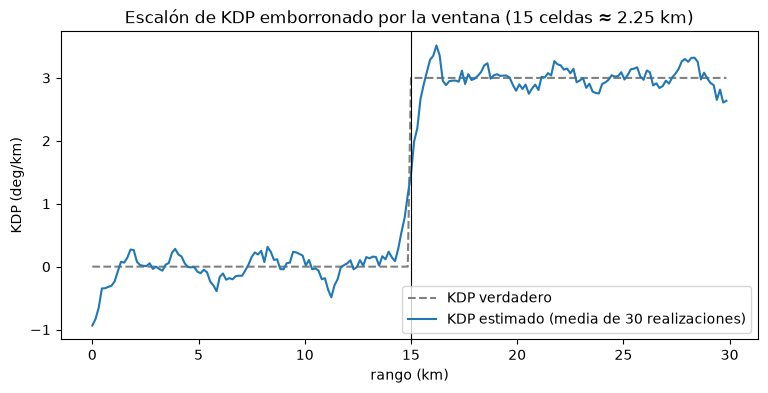

cruce del 50% del escalón a 1 celdas del escalón verdadero (ventana=15 celdas)


In [5]:
STEP_INDEX = 100
K0_STEP = 3.0
N_REALIZATIONS_STEP = 30

kdp_true_step = np.where(np.arange(N_GATES) < STEP_INDEX, 0.0, K0_STEP)
kdp_hats_step = []
for _ in range(N_REALIZATIONS_STEP):
    _, phidp_unwrapped = simulate_phidp_profile(kdp_true_step, 0.97, 64)
    kdp_hats_step.append(kdp_window_fit(phidp_unwrapped, R_KM, WINDOW_GATES))
kdp_hat_step_mean = np.nanmean(kdp_hats_step, axis=0)

crossing_idx = np.argmax(kdp_hat_step_mean[STEP_INDEX - 20:STEP_INDEX + 20] > K0_STEP / 2.0) + (STEP_INDEX - 20)
crossing_offset_gates = abs(crossing_idx - STEP_INDEX)

fig, ax = plt.subplots()
ax.plot(R_KM, kdp_true_step, "--", color="gray", label="KDP verdadero")
ax.plot(R_KM, kdp_hat_step_mean, label="KDP estimado (media de 30 realizaciones)")
ax.axvline(R_KM[STEP_INDEX], color="black", linewidth=0.8)
ax.set_xlabel("rango (km)"); ax.set_ylabel("KDP (deg/km)"); ax.legend()
ax.set_title(f"Escalón de KDP emborronado por la ventana ({WINDOW_GATES} celdas ≈ {WINDOW_GATES*GATE_SPACING_KM:.2f} km)")
plt.show()

print(f"cruce del 50% del escalón a {crossing_offset_gates} celdas del escalón verdadero "
      f"(ventana={WINDOW_GATES} celdas)")
checks.append((f"el cruce del 50% del escalón cae dentro de la propia ventana ({WINDOW_GATES} celdas)",
               crossing_offset_gates <= WINDOW_GATES))

## Prueba 3 — tramo nulo: sin sesgo negativo sistemático ni oscilación

KDP verdadero cero en toda la traza, con el ruido de fase real de la
simulación. La página es explícita: el estimador no debe generar KDP
negativo sistemático (importa para no reportar lluvia negativa) ni
oscilaciones — un `std` grande indicaría un filtro que amplifica el ruido de
fase en vez de suavizarlo.

In [6]:
N_REALIZATIONS_NULL = 30
NULL_BIAS_TOLERANCE = 0.05
NULL_STD_TOLERANCE = 1.2  # genuino: derivar amplifica ruido (ver la propia página) — calibrado
# contra el std medido a W=15 (~0.9 deg/km); la sección de compromiso de ventana, justo debajo,
# muestra que W=31 lo baja a ~0.4 y W=5 lo dispara a >5 — esto no es un fallo del estimador,
# es la razón de que la longitud de ventana sea el parámetro que hay que elegir con cuidado

kdp_hats_null = []
for _ in range(N_REALIZATIONS_NULL):
    _, phidp_unwrapped = simulate_phidp_profile(np.zeros(N_GATES), 0.97, 64)
    kdp_hats_null.append(kdp_window_fit(phidp_unwrapped, R_KM, WINDOW_GATES))
kdp_hats_null = np.array(kdp_hats_null)
null_mean = np.nanmean(kdp_hats_null[:, edge:-edge])
null_std = np.nanstd(kdp_hats_null[:, edge:-edge])
print(f"KDP sobre tramo nulo: media={null_mean:.4f} deg/km  std={null_std:.4f} deg/km")

checks.append((f"sin KDP negativo sistemático en tramo nulo (|media| < {NULL_BIAS_TOLERANCE} deg/km)",
               abs(null_mean) < NULL_BIAS_TOLERANCE))
checks.append((f"sin oscilación excesiva en tramo nulo (std < {NULL_STD_TOLERANCE} deg/km)",
               null_std < NULL_STD_TOLERANCE))

KDP sobre tramo nulo: media=0.0098 deg/km  std=0.8903 deg/km


## Compromiso resolución/ruido con la longitud de ventana

La página lo describe en prosa; aquí se cuantifica con el mismo escenario
de escalón: ventana corta responde más rápido pero con más ruido, ventana
larga suaviza el ruido pero emborrona más el escalón.

In [7]:
WINDOW_GRID = [5, 15, 31]
print(f"{'ventana':>8} {'std(tramo plano)':>18} {'ancho de emborronado (celdas)':>30}")
for w in WINDOW_GRID:
    _, phidp_flat = simulate_phidp_profile(np.zeros(N_GATES), 0.97, 64)
    kdp_flat = kdp_window_fit(phidp_flat, R_KM, w)
    std_flat = np.nanstd(kdp_flat[w:-w])

    kdp_step_realizations = []
    for _ in range(20):
        _, phidp_step = simulate_phidp_profile(kdp_true_step, 0.97, 64)
        kdp_step_realizations.append(kdp_window_fit(phidp_step, R_KM, w))
    kdp_step_mean = np.nanmean(kdp_step_realizations, axis=0)
    cross = np.argmax(kdp_step_mean[STEP_INDEX - 25:STEP_INDEX + 25] > K0_STEP / 2.0) + (STEP_INDEX - 25)
    print(f"{w:8d} {std_flat:18.4f} {abs(cross - STEP_INDEX):30d}")

 ventana   std(tramo plano)  ancho de emborronado (celdas)


       5             5.3115                             24


      15             0.9984                              1


      31             0.4068                              0


## Fuera de alcance, declarado

- **Censura previa por ρHV bajo**: la dependencia dura con
  `polarimetria-covarianzas.md` ya está cubierta allí (la resta de ruido por
  canal y la censura cuando `P_h`/`P_v` no superan el umbral); este oráculo
  no repite esa validación, asume perfiles ya censurados aguas arriba, tal
  como la página describe el orden de la cadena.
- **Variantes adaptativas y variacionales** (Wang & Chandrasekar 2009;
  Vulpiani et al. 2012; Maesaka et al. 2012): la propia página las deja como
  mejora posterior a la ventana fija de Stage 1, que es el alcance de este
  oráculo.
- **Contraste contra Py-ART**: declarado arriba, no disponible en esta
  sesión.

In [8]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de KDP no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] sesgo de KDP < 0.3 deg/km en toda la malla (ρHV, M)
[OK] el cruce del 50% del escalón cae dentro de la propia ventana (15 celdas)
[OK] sin KDP negativo sistemático en tramo nulo (|media| < 0.05 deg/km)
[OK] sin oscilación excesiva en tramo nulo (std < 1.2 deg/km)

Todas las comprobaciones dentro de tolerancia.
